100%|██████████| 5000/5000 [00:43<00:00, 114.71it/s]


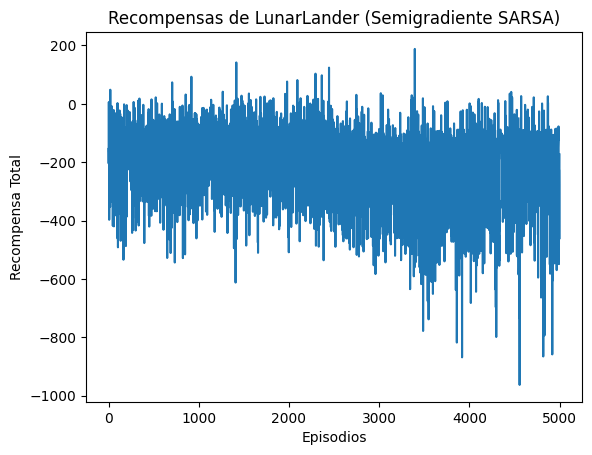

Recompensa promedio de los últimos 100 episodios: -191.3776044675766


In [ ]:
from tqdm import tqdm
import random
import numpy as np
import gymnasium as gym
from agents import TileCodingEnv, LunarAgentSARSA

random.seed(42)
np.random.seed(42)

def train_agent_SARSA(agent, n_episodes, saving=False):
    saved_episodes = []
    n_save = max(1, n_episodes // 10)
    
    def save_episode(episode_num):
        return episode_num % n_save == 0
    
    env = agent.env

    for n in tqdm(range(n_episodes)):
        # Start a new episode (obs ya es una lista de features activas gracias al Wrapper)
        obs, info = env.reset()
        done = False
        episode_history = []

        # Play one complete episode
        action, is_exploring = agent.get_action(obs)                            
        
        while not done:
            next_obs, reward, terminated, truncated, info = env.step(action)        

            next_action, next_is_exploring = agent.get_action(next_obs)                  
            
            # Update Q-values (Semigradient SARSA)
            agent.update(obs, action, reward, terminated, next_obs, next_action)    

            # Move to next state
            done = terminated or truncated
            obs = next_obs
            action = next_action
            is_exploring = next_is_exploring

        # Reduce exploration rate (agent becomes less random over time)
        agent.decay_epsilon()
        
    if saving:
        return saved_episodes

# ----- CONFIGURACIÓN Y EJECUCIÓN -----

learning_rate, n_episodes = (0.2, 5000) # LunarLander puede necesitar bastantes episodios

# # Creamos el entorno original y lo envolvemos en nuestro Tile Coder
# base_env = gym.make("LunarLander-v3")
# # 4 bins por cada una de las 8 dimensiones
bins = np.array([4, 4, 4, 4, 4, 4, 2, 2])  # número de intervalos por dimensión
# env = LunarLanderTileCoding(base_env, bins=bins, n_tilings=8)

# # Utilizamos RecordEpisodeStatistics para el tracking (requiere acceder a env.unwrapped.return_queue)
# env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

initial_epsilon = 1.0
final_epsilon = 0.05
ratio = 0.8 # Exploramos durante el 80% del entrenamiento

# agent = LunarAgentSARSA(
#     env=env,
#     learning_rate=learning_rate,
#     initial_epsilon=initial_epsilon,
#     epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
#     final_epsilon=final_epsilon,
#     decay_type="linear"
# )

# 1. Creamos el entorno base (v3)
base_env = gym.make("LunarLander-v3")

# 2. Aplicamos TU Tile Coding
# Suponiendo que bins y n_tilings están definidos
tile_env = TileCodingEnv(base_env, bins=bins, low=base_env.observation_space.low, high=base_env.observation_space.high, n=1)

# 3. Guardamos los datos necesarios ANTES de envolverlo con estadísticas
n_tilings = tile_env.n_tilings
total_features = tile_env.total_features

# 4. Envolvemos para estadísticas
env = gym.wrappers.RecordEpisodeStatistics(tile_env, buffer_length=n_episodes)
env.total_features = total_features
env.n_tilings = n_tilings

# 5. Pasamos el entorno al agente
# El agente ahora podrá acceder a n_tilings si lo modificamos ligeramente 
# o si usamos las variables que ya extrajimos.
agent = LunarAgentSARSA(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=initial_epsilon,
    epsilon_decay=(initial_epsilon - final_epsilon) / (n_episodes * ratio),
    final_epsilon=final_epsilon,
    decay_type="linear"
)

saved_episodes = train_agent_SARSA(agent, n_episodes, saving=True)

# Evaluación rápida usando la cola de recompensas del wrapper
import matplotlib.pyplot as plt
returns = np.array(env.return_queue).flatten()
plt.plot(returns)
plt.title('Recompensas de LunarLander (Semigradiente SARSA)')
plt.xlabel('Episodios')
plt.ylabel('Recompensa Total')
plt.show()

print(f"Recompensa promedio de los últimos 100 episodios: {np.mean(returns[-100:])}")

# Nota: Tus funciones utils.plot_training_metrics y taxi_gif.animar_estados_taxi_gif
# deben ser reescritas para procesar imágenes continuas si quieres usarlas aquí.

In [ ]:
import gymnasium as gym
import numpy as np

def visualize_solution(agent, env_name="LunarLander-v3", bins=None, n_tilings=1, seed=None):
    # Creamos el entorno base con render
    base_env = gym.make(env_name, render_mode="human")
    
    # Envolvemos con Tile Coding si bins fueron proporcionados
    if bins is not None:
        # Extraemos los límites del espacio de observación del entorno base
        low = base_env.observation_space.low
        high = base_env.observation_space.high
        
        # Pasamos low, high, y usamos 'n' en lugar de 'n_tilings'
        tile_env = TileCodingEnv(base_env, bins=bins, low=low, high=high, n=n_tilings)
    else:
        tile_env = base_env  # si no usamos Tile Coding

    # Recordamos estadísticas (opcional)
    env = gym.wrappers.RecordEpisodeStatistics(tile_env, buffer_length=1)
    
    obs, info = env.reset(seed=seed)
    done = False
    total_reward = 0
    step_count = 0
    
    while not done:
        # obs ya está en formato Tile Coding si usamos tile_env
        action, _ = agent.get_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step_count += 1

    print(f"Total reward del episodio visualizado: {total_reward:.2f}")
    env.close()

# ----- USO -----
# Reutiliza los bins y n_tilings que usaste para entrenar
visualize_solution(agent, bins=np.array([4,4,4,4,4,4,2,2]), n_tilings=1)

IndexError: index 6507 is out of bounds for axis 0 with size 2916

: 

In [5]:
# Q-Learning profe
for episode in range(num_episodes):
    obs, info = tcenv.reset()
    active_features = tcenv.last_active_features

    total_reward = 0.0

    for t in range(max_steps):
        # Selección de acción (exploración sigue siendo epsilon-greedy)
        a = epsilon_greedy_policy(active_features, w, num_actions, epsilon)

        obs_next, reward, done, truncated, info = tcenv.step(a)
        total_reward += reward

        active_features_next = tcenv.last_active_features

        # Calcular Q(s,a)
        q_sa = q_value(active_features, a, w)

        if not (done or truncated):
            # Q-Learning: usar máximo
            q_vals_next = compute_q_values(active_features_next, num_actions, w)
            max_q_next = np.max(q_vals_next)
            delta = reward + gamma * max_q_next - q_sa
        else:
            delta = reward - q_sa

        # Actualizar pesos (solo features activas)
        for i in active_features:
            w[i, a] += alpha * delta

        if done or truncated:
            break

        active_features = active_features_next

    returns.append(total_reward)

NameError: name 'num_episodes' is not defined